## Titanic - Machine Learning from Disaster

This notebook focuses on loading the Kaggle Titanic data and preparing a clean, analysis-ready table.


### Imports

We keep the stack minimal: pandas for data tables and numpy for numeric helpers.


In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm


### Load data

The CSV files live in the `Data` folder, so we load them with explicit paths to keep the notebook portable.


In [136]:
train_path = 'Data/train.csv'
test_path = 'Data/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Quick shape + missingness scan

Before any preprocessing, we check data size and the columns with NaNs so we can justify each fix.


In [137]:
print('train:', train_df.shape)
print('test :', test_df.shape)

missing_train = train_df.isna().sum().sort_values(ascending=False)
missing_test = test_df.isna().sum().sort_values(ascending=False)

missing_train[missing_train > 0]


train: (891, 12)
test : (418, 11)


Cabin       687
Age         177
Embarked      2
dtype: int64

### Preprocessing decisions

- **Age**: fill with the median within each `Pclass` + `Sex` group (keeps class/sex effects); any remaining NaNs fall back to the global median.
- **Embarked**: fill with the mode since it's categorical and has very few missing values.
- **Fare**: fill with the median because it's numeric and skewed.
- **Cabin**: keep it as a feature, but simplify it by taking the first letter (deck). Missing cabins become `U` for unknown.
- **Title**: extract from `Name` (e.g., Mr, Mrs, Miss) as a compact social-status proxy.
- **Family size**: `SibSp + Parch + 1` to capture social support; `IsAlone` flags solo travelers.
- **Age bins**: label children vs adults to compare survival patterns; in the final dataset we keep `AgeBin` and drop raw `Age`.
- **Ticket/Name**: drop for now to keep the baseline simple (high cardinality).


In [138]:
def preprocess(df):
    df = df.copy()

    if 'Name' in df.columns:
        df['Title'] = df['Name'].astype(str).str.extract(r' ([A-Za-z]+)\.', expand=False)
        df['Title'] = df['Title'].fillna('Unknown')
        

    drop_cols = ['Ticket', 'Name']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    if 'Cabin' in df.columns:
        df['Cabin'] = df['Cabin'].fillna('Unknown')
        df['CabinType'] = df['Cabin'].astype(str).str[0]
        df['CabinType'] = df['CabinType'].fillna('U')
        df = df.drop(columns=['Cabin'])

    if {'SibSp', 'Parch'}.issubset(df.columns):
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['IsAlone'] = (df['FamilySize'] == 1).map({True: 'Yes', False: 'No'})


    if 'Embarked' in df.columns:
        mode = df['Embarked'].mode(dropna=True)
        if not mode.empty:
            df['Embarked'] = df['Embarked'].fillna(mode.iloc[0])

    if 'Fare' in df.columns:
        df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    if 'Age' in df.columns:
        if {'Pclass', 'Sex'}.issubset(df.columns):
            df['Age'] = df['Age'].fillna(
                df.groupby(['Pclass', 'Sex'])['Age'].transform('median')
            )
        df['Age'] = df['Age'].fillna(df['Age'].median())
        df['AgeBin'] = df['Age'].apply(lambda x: 'Child' if x < 16 else 'Adult')
        df = df.drop(columns=['Age'])


    return df

train_clean = preprocess(train_df)
test_clean = preprocess(test_df)

train_clean.isna().sum().sort_values(ascending=False).head(15)


PassengerId    0
Survived       0
Pclass         0
Sex            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Title          0
CabinType      0
FamilySize     0
IsAlone        0
AgeBin         0
dtype: int64

### Visualize key distributions vs survival

We plot histograms for `Age`, `Pclass`, and `SibSp` with the bars split by survival so we can spot where class/age/family size influence outcomes.


### Cabin reported vs missing

Cabin has many missing values. Here we compare survival rates for passengers with a recorded cabin versus those without to see if missingness itself is informative.


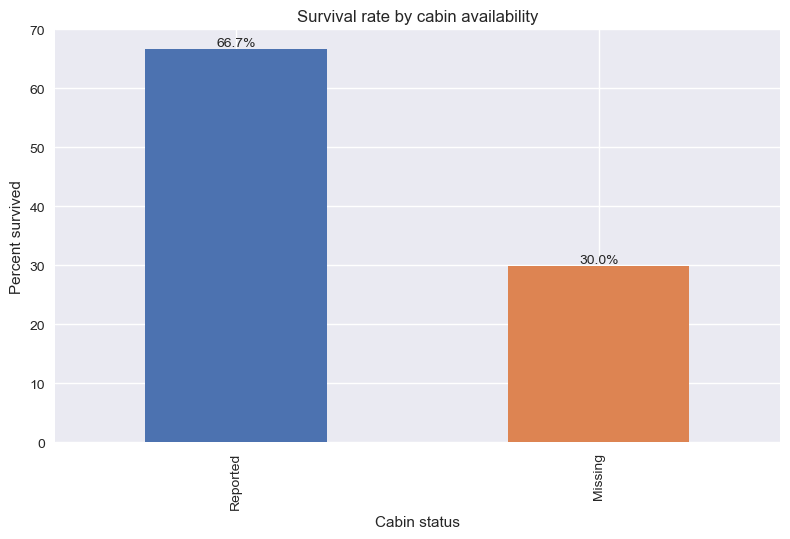

['U' 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']


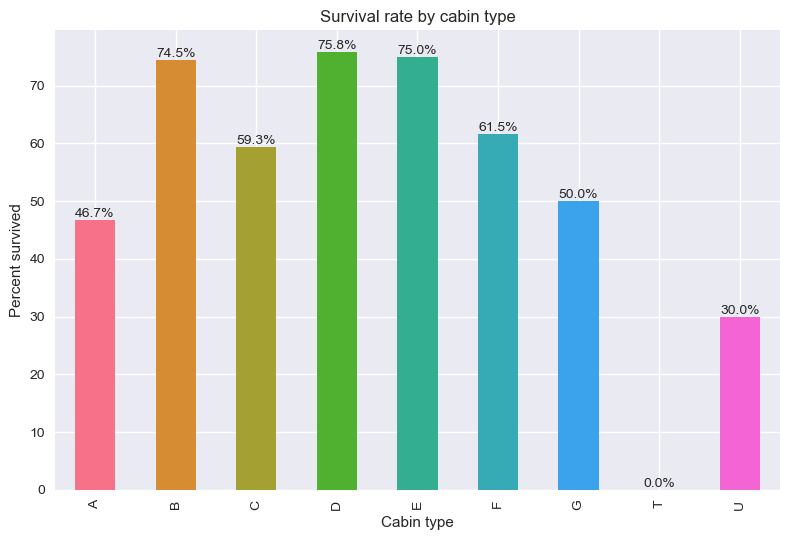

In [139]:
cabin_df = train_df.copy()
cabin_df['CabinReported'] = cabin_df['Cabin'].notna().map({True: 'Reported', False: 'Missing'})

survival_pct = (
    cabin_df.groupby('CabinReported')['Survived']
    .mean()
    .mul(100)
    .reindex(['Reported', 'Missing'])
)

ax = survival_pct.plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_title('Survival rate by cabin availability')
ax.set_ylabel('Percent survived')
ax.set_xlabel('Cabin status')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.tight_layout()
plt.show()

# Map nan cabin type to 'Unknown' for analysis
cabin_df['Cabin'] = cabin_df['Cabin'].fillna('Unknown')
cabin_df['cabin_type'] = cabin_df['Cabin'].str[0]
cabin_survival = (
    cabin_df.groupby('cabin_type')['Survived']
    .mean()
    .mul(100)
    .sort_index()
)
ax = cabin_survival.plot(kind='bar', color=sns.color_palette('husl', n_colors=len(cabin_survival)))
ax.set_title('Survival rate by cabin type')
ax.set_ylabel('Percent survived')
ax.set_xlabel('Cabin type')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.tight_layout()
print(cabin_df['cabin_type'].unique())



### Title extraction analysis

Titles in passenger names can proxy social status and family role. We extract them and compare survival rates by title.


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64


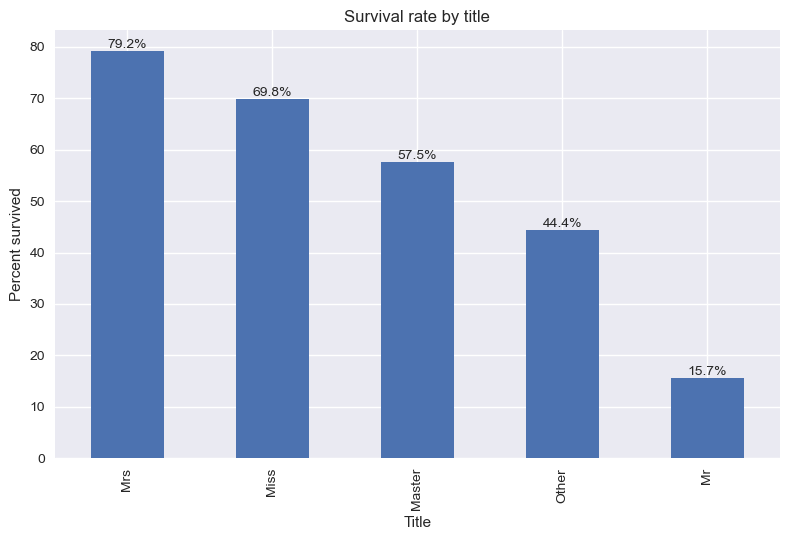

In [140]:
title_df = train_df.copy()
title_df['Title'] = title_df['Name'].astype(str).str.extract(r' ([A-Za-z]+)\.', expand=False)
title_df['Title'] = title_df['Title'].fillna('Unknown')

survival_by_title = (
    title_df.groupby('Title')['Survived']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
# Number of people with each title
title_counts = title_df['Title'].value_counts()
print(title_counts)
# Only keep titles with more than 10 occurrences, set others to 'Other'
common_titles = title_counts[title_counts > 10].index
title_df.loc[~title_df['Title'].isin(common_titles), 'Title'] = 'Other'
survival_by_title = (
    title_df.groupby('Title')['Survived']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

ax = survival_by_title.plot(kind='bar', color='#4C72B0')
ax.set_title('Survival rate by title')
ax.set_ylabel('Percent survived')
ax.set_xlabel('Title')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.tight_layout()


### Family size, alone, and age bins

These engineered features capture social context: family size, whether a passenger was traveling alone, and a simple child/adult split for age.


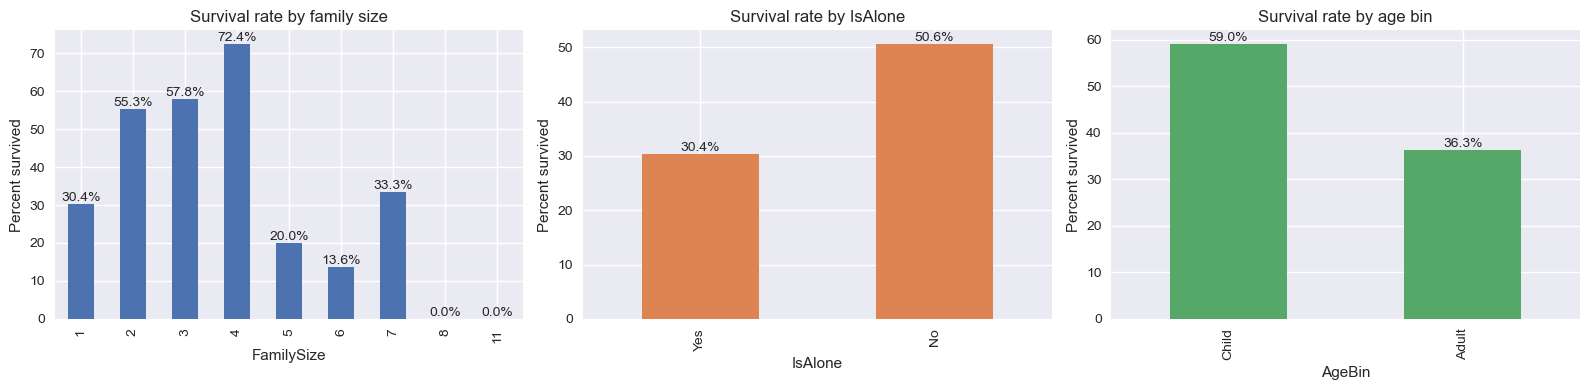

In [141]:
fs_df = train_clean.copy()
# Survival rate by family size
family_survival = (
    fs_df.groupby('FamilySize')['Survived']
    .mean()
    .mul(100)
)


# Survival rate by alone status
alone_survival = (
    fs_df.groupby('IsAlone')['Survived']
    .mean()
    .mul(100)
    .reindex(['Yes', 'No'])
)

# Survival rate by age bin
agebin_survival = (
    fs_df.groupby('AgeBin')['Survived']
    .mean()
    .mul(100)
    .reindex(['Child', 'Adult'])
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

family_survival.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Survival rate by family size')
axes[0].set_ylabel('Percent survived')
axes[0].set_xlabel('FamilySize')
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%')

alone_survival.plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Survival rate by IsAlone')
axes[1].set_ylabel('Percent survived')
axes[1].set_xlabel('IsAlone')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%')

agebin_survival.plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Survival rate by age bin')
axes[2].set_ylabel('Percent survived')
axes[2].set_xlabel('AgeBin')
axes[2].bar_label(axes[2].containers[0], fmt='%.1f%%')

plt.tight_layout()



Survival rate by Pclass:
Pclass 1: 62.96% survived
Pclass 2: 47.28% survived
Pclass 3: 24.24% survived


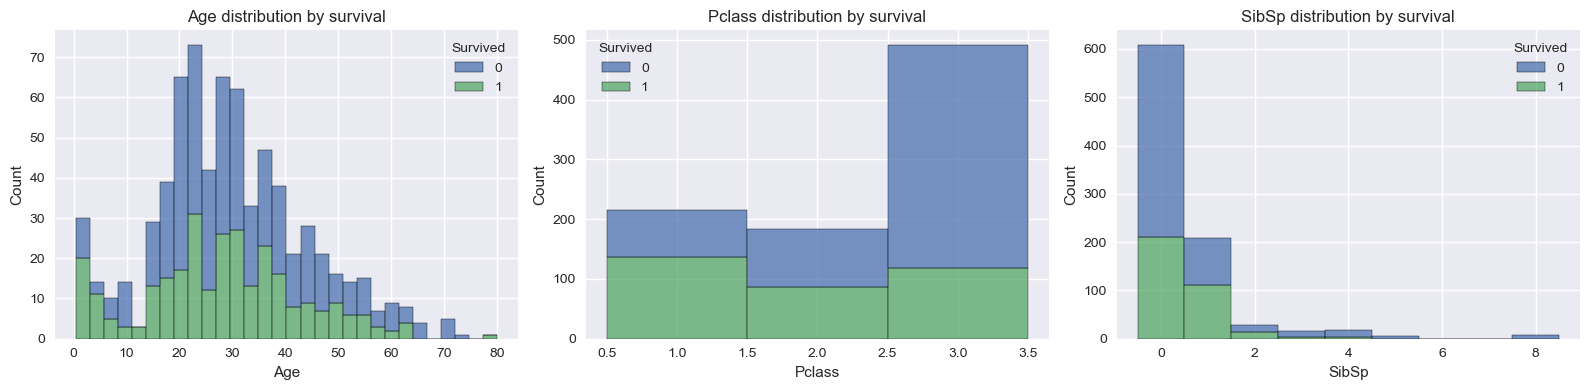

In [142]:
# Use raw train_df to keep target column intact
viz_df = train_df.copy()

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=viz_df, x='Age', hue='Survived', bins=30, multiple='stack', ax=axes[0])
axes[0].set_title('Age distribution by survival')

sns.histplot(data=viz_df, x='Pclass', hue='Survived', discrete=True, multiple='stack', ax=axes[1])
axes[1].set_title('Pclass distribution by survival')

sns.histplot(data=viz_df, x='SibSp', hue='Survived', discrete=True, multiple='stack', ax=axes[2])
axes[2].set_title('SibSp distribution by survival')

for ax in axes:
    ax.set_xlabel(ax.get_xlabel())
    ax.set_ylabel('Count')

plt.tight_layout()

# for Pclass print % survived
pclass_survival = viz_df.groupby('Pclass')['Survived'].mean() * 100
print('\nSurvival rate by Pclass:')
for pclass, survival_rate in pclass_survival.items():
    print(f'Pclass {pclass}: {survival_rate:.2f}% survived')
    


### Feature engineering ideas

From these distributions, we can design features that better capture survival patterns:

- **Age bins**: children vs adults are likely to have different survival rates.
- **Family size**: combine `SibSp` + `Parch` + 1 into a `FamilySize` feature, and optionally `IsAlone`.
- **Cabin deck**: if you later bring `Cabin` back, the deck letter (A/B/C/...) can be a strong signal even if many are missing.
- **Title extraction**: parse `Name` to extract titles (Mr, Mrs, Miss, etc.) as a social-status proxy.
- **Fare per person**: normalize `Fare` by family size to reduce wealth confounding.

These are lightweight features that typically boost baseline performance without heavy modeling.


### PCA (2D projection)

We use PCA to project the feature space into 2D so we can visually check if survivors and non-survivors separate. PCA captures variance, not target importance, so treat this as exploratory.


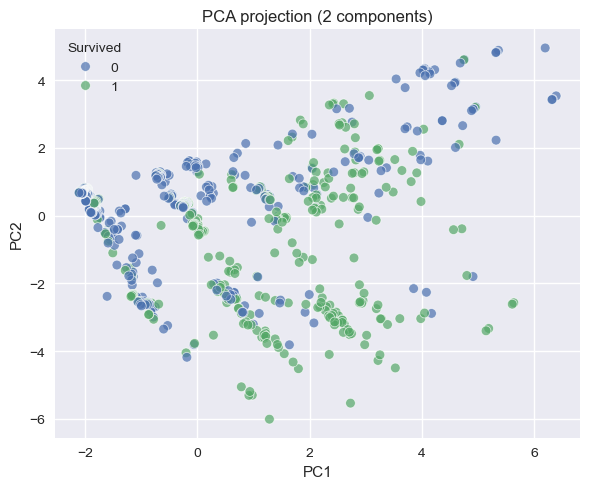

In [143]:
# Build a modeling table (exclude target and non-numeric IDs)
features = train_clean.drop(columns=['Survived'])

# One-hot encode categoricals
features_encoded = pd.get_dummies(features, columns=['Sex', 'Embarked', 'CabinType', 'Title', 'IsAlone', 'AgeBin'], drop_first=True)

# Standardize numeric scale before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_encoded)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Survived': train_clean['Survived'].values
})

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Survived', alpha=0.7)
plt.title('PCA projection (2 components)')
plt.tight_layout()


In [144]:
train_clean.head()
train_clean['Title'].unique()


array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

### Final feature engineering

We keep only titles that appear at least 10 times in the training set. Rare titles are grouped as `Rare` so the model sees stable categories. We also keep `FamilySize`, `IsAlone`, `CabinType`, and `AgeBin` (dropping raw `Age`).


In [145]:
def finalize_features(train_df, test_df, min_title_count=10):
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Determine which titles are frequent enough to keep
    title_counts = train_df['Title'].value_counts()
    keep_titles = title_counts[title_counts >= min_title_count].index

    train_df['Title'] = train_df['Title'].where(train_df['Title'].isin(keep_titles), 'Rare')
    test_df['Title'] = test_df['Title'].where(test_df['Title'].isin(keep_titles), 'Rare')

    # Ensure Age is not present (we keep AgeBin only)
    for df in (train_df, test_df):
        if 'Age' in df.columns:
            df.drop(columns=['Age'], inplace=True)

    return train_df, test_df, keep_titles

final_train_df, final_test_df, kept_titles = finalize_features(train_clean, test_clean)

final_train_df.head()


,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked,Title,CabinType,FamilySize,IsAlone,AgeBin
0,1,0,3,male,1,0,7.2500,S,Mr,U,2,No,Adult
1,2,1,1,female,1,0,71.2833,C,Mrs,C,2,No,Adult
2,3,1,3,female,0,0,7.9250,S,Miss,U,1,Yes,Adult
3,4,1,1,female,1,0,53.1000,S,Mrs,C,2,No,Adult
4,5,0,3,male,0,0,8.0500,S,Mr,U,1,Yes,Adult


### Random Forest with 5-fold validation

We use 5-fold cross-validation (each fold uses 4/5 for training, 1/5 for validation) to estimate generalization error. We then compare training vs validation error across hyperparameters.


In [146]:
# Prepare features and target
model_df = final_train_df.copy()
X = model_df.drop(columns=['Survived'])
y = model_df['Survived']

# One-hot encode categoricals for the model
X = pd.get_dummies(X, columns=['Sex', 'Embarked', 'CabinType', 'Title', 'IsAlone', 'AgeBin'], drop_first=True)

# Hyperparameter grid
n_estimators_list = [50, 100, 200, 300]
max_depth_list = [3, 5, 8, None]

results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [(n, d) for n in n_estimators_list for d in max_depth_list]

for n_estimators, max_depth in tqdm(param_grid, desc='RF hyperparams'):
    train_errors = []
    val_errors = []
    for train_idx, val_idx in cv.split(X, y):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train, y_train)

            train_err = 1 - model.score(X_train, y_train)
            val_err = 1 - model.score(X_val, y_val)

            train_errors.append(train_err)
            val_errors.append(val_err)

    results.append({
        'n_estimators': n_estimators,
        'max_depth': max_depth if max_depth is not None else 'None',
        'train_error': sum(train_errors) / len(train_errors),
        'val_error': sum(val_errors) / len(val_errors)
    })

results_df = pd.DataFrame(results)
results_df.head()


RF hyperparams: 100%|██████████| 16/16 [00:30<00:00,  1.88s/it]


,n_estimators,max_depth,train_error,val_error
0,50,3,0.177328,0.184063
1,50,5,0.156847,0.169475
2,50,8,0.091470,0.164999
3,50,None,0.001122,0.189712
4,100,3,0.176767,0.176216


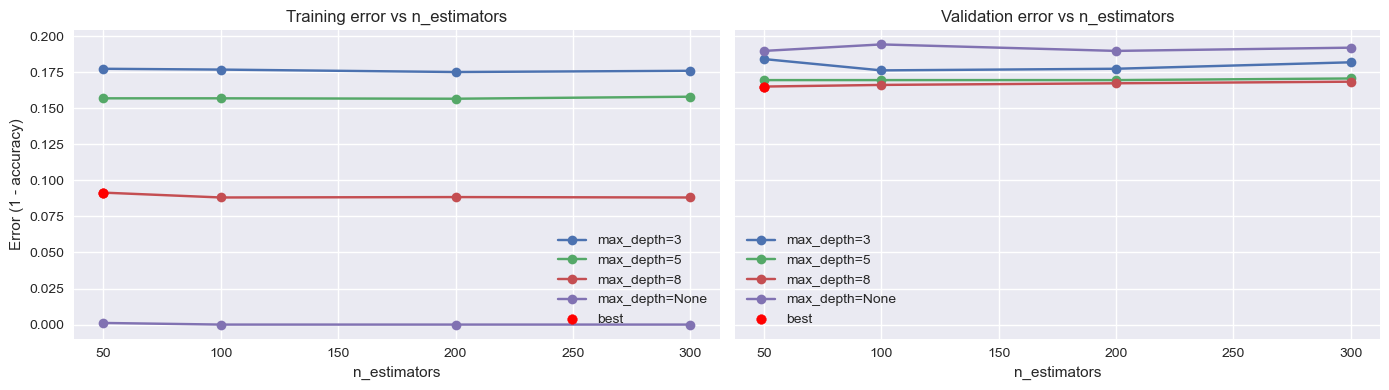

In [147]:
# Identify best hyperparameters by lowest validation error
best_idx = results_df['val_error'].idxmin()
best_row = results_df.loc[best_idx]
best_n_estimators = int(best_row['n_estimators'])
best_max_depth = best_row['max_depth']

# Plot training vs validation error across hyperparameters
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for max_depth in results_df['max_depth'].unique():
    subset = results_df[results_df['max_depth'] == max_depth]
    axes[0].plot(subset['n_estimators'], subset['train_error'], marker='o', label=f'max_depth={max_depth}')
    axes[1].plot(subset['n_estimators'], subset['val_error'], marker='o', label=f'max_depth={max_depth}')

axes[0].set_title('Training error vs n_estimators')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Error (1 - accuracy)')
axes[1].set_title('Validation error vs n_estimators')
axes[1].set_xlabel('n_estimators')

# Mark best hyperparameters on both plots
axes[0].scatter(best_n_estimators, best_row['train_error'], color='red', zorder=5, label='best')
axes[1].scatter(best_n_estimators, best_row['val_error'], color='red', zorder=5, label='best')

axes[0].legend()
axes[1].legend()
plt.tight_layout()


In [148]:
# train using best hyperparameters on full training set
model = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth if best_max_depth != 'None' else None,
    random_state=42,
    n_jobs=-1
)
model.fit(X, y)

# Get accuracy on training set
train_accuracy = model.score(X, y)
print(f'Training accuracy with best hyperparameters: {train_accuracy:.4f}')


Training accuracy with best hyperparameters: 0.9012


### Train final model and create submission

We train a final Random Forest using the best hyperparameters from validation, then generate predictions for the Kaggle submission file.


In [149]:
# Build aligned train/test matrices
train_model_df = final_train_df.copy()
test_model_df = final_test_df.copy()

X_train = train_model_df.drop(columns=['Survived'])
y_train = train_model_df['Survived']
X_test = test_model_df.copy()

X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked', 'CabinType', 'Title', 'IsAlone', 'AgeBin'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Sex', 'Embarked', 'CabinType', 'Title', 'IsAlone', 'AgeBin'], drop_first=True)

# Align columns between train and test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Train final model
final_model = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=None if best_max_depth == 'None' else best_max_depth,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train, y_train)

# Predict and create submission
test_predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_model_df['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('submission.csv', index=False)
submission.head()


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,0
